# HYCOM vertical coordinate comparison

This notebook compares the default HYCOM coordinate with those generated in `input/anu-tub/hycomlike-vertical-grids.ipynb`.
All vertical grids use the the *same target potential densities* for the interfaces, but have different minimum depths at which the target potential densities are found.
The point behind the change is to transition to isopycnals at shallower depths in the high latitudes but retain the same zstar structure in the upper ocean.

In [1]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar
│        - hycom
│        - dz3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


## After one month

In both cases, the initial conditions are `input/anu-tub/hycom_initial_conditions.nc`.
We look at the vertical structure after the experiments have been run for one month.

In [2]:
# alt HYCOM
output_path = joinpath(tub_output_dir, "anu-tub-nm-alt-hycom", "output000")
static = joinpath(output_path, "ocean_static.nc")
monthly = joinpath(output_path, "ocean_month.nc")
zmonthly = joinpath(output_path, "ocean_month_z.nc")

# HYCOM default
doutput_path = joinpath(tub_output_dir, "anu-tub-nm-hycom", "output000")
dmonthly = joinpath(doutput_path, "ocean_month.nc")
dzmonthly = joinpath(doutput_path, "ocean_month_z.nc")

"/g/data/e14/jb2381/anu-tub/outputs/anu-tub-nm-hycom/output000/ocean_month_z.nc"

## South-north transect

In [3]:
ds = NCDataset(monthly, maskingvalue = NaN)
h = ds["thkcello"][:, :, :, :]
close(ds)

∫h = cumsum(h, dims = 3)

ds = NCDataset(zmonthly, maskingvalue = NaN)
σ₂ = ds["rhopot2"][:, :, :, :]
xh = ds["xh"][:]
yh = ds["yh"][:]
zl = ds["z_l"][:]
close(ds)

ds = NCDataset(dmonthly, maskingvalue = NaN)
dh = ds["thkcello"][:, :, :, :]
close(ds)

∫dh = cumsum(dh, dims = 3)

ds = NCDataset(dzmonthly, maskingvalue = NaN)
dσ₂ = ds["rhopot2"][:, :, :, :]
xh = ds["xh"][:]
yh = ds["yh"][:]
zl = ds["z_l"][:]
close(ds)

closed Dataset

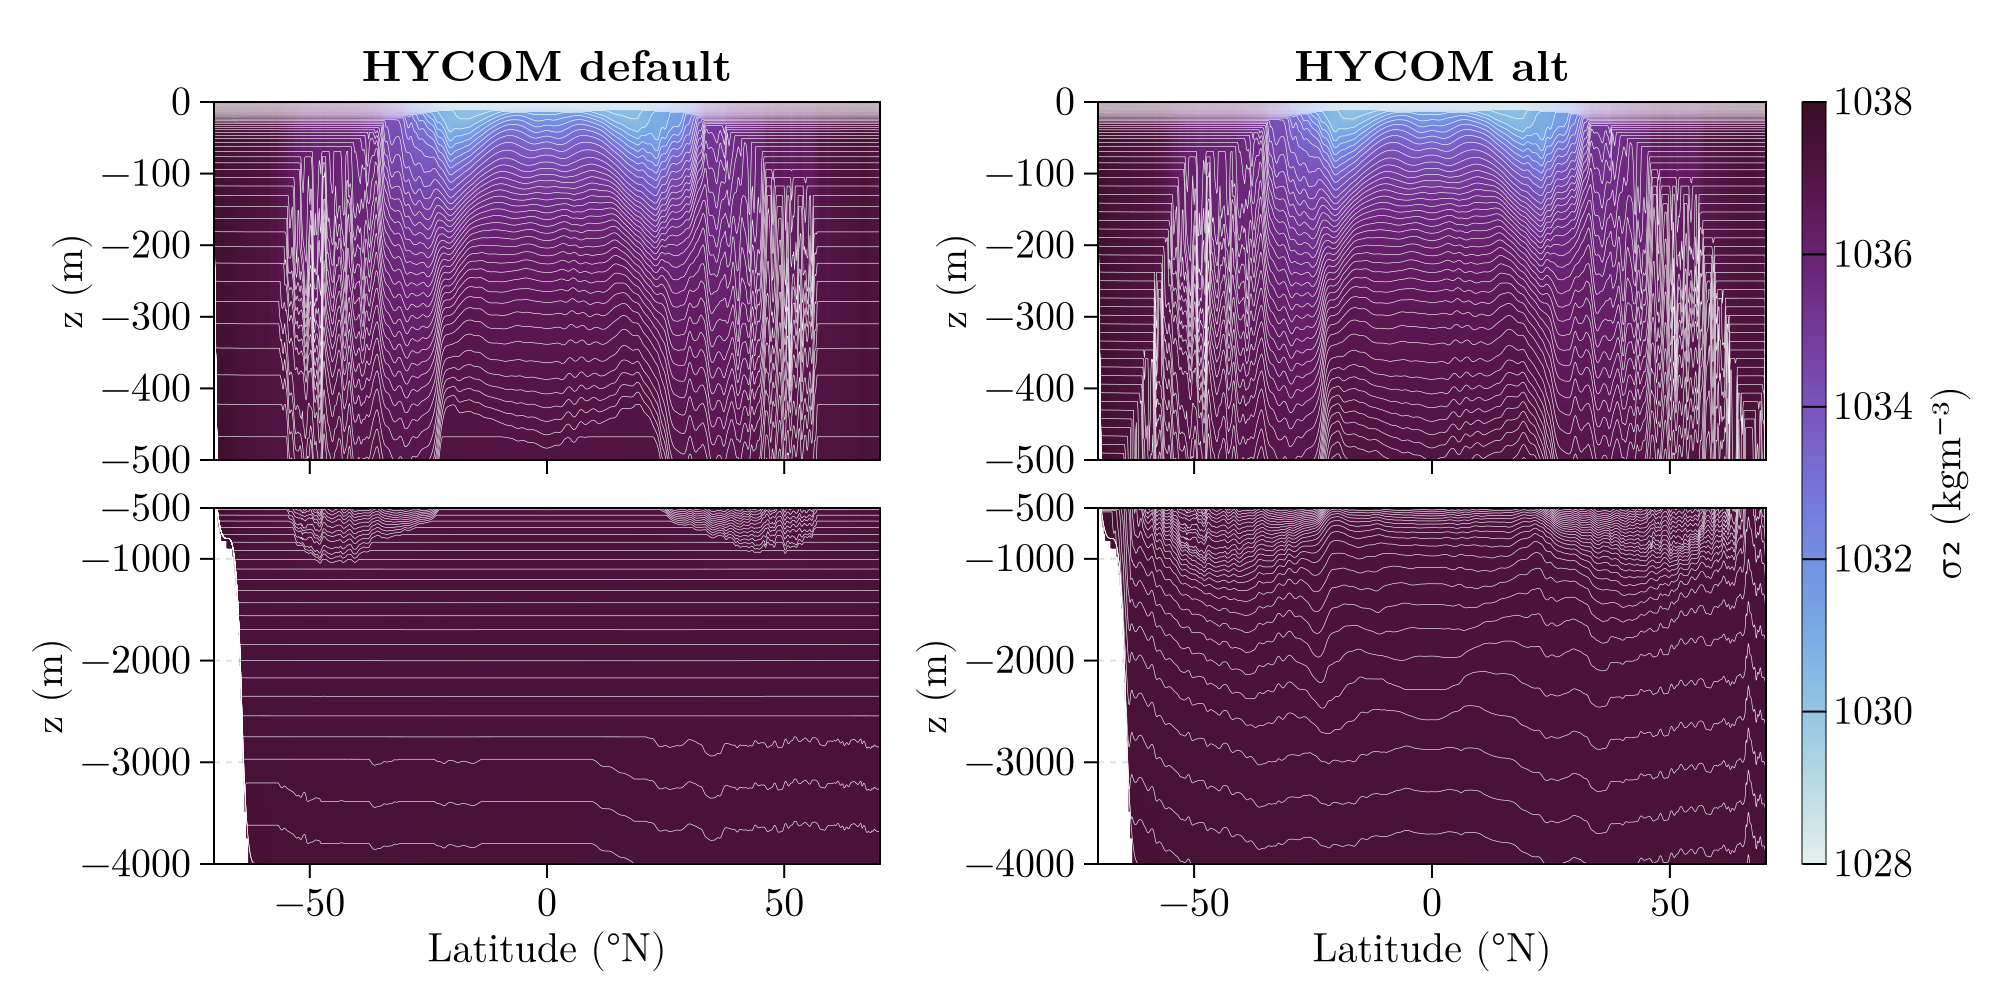

In [4]:
lon = 80
t = 1

fig = Figure(size = (1000, 500))

colormap = :dense
colorrange = (1028, 1038)
depth_levels = 1:75

# Hycom default
axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "HYCOM default")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, -zl[depth_levels], dσ₂[lon, :, depth_levels, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axtop, yh, -∫dh[lon, :, i, t], color = :white, linewidth = 0.3)
end
ylims!(axtop, -500, 0)
axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, yh, -zl[depth_levels], dσ₂[lon, :, depth_levels, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axbot, yh, -∫dh[lon, :, i, t], color = :white, linewidth = 0.3)
end
ylims!(axbot, -4000, -500)
axbot.yticks = [-4000, -3000, -2000, -1000, -500]

# Modified
axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "HYCOM alt")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, -zl[depth_levels], σ₂[lon, :, depth_levels, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axtop, yh, -∫h[lon, :, i, t], color = :white, linewidth = 0.3)
end
ylims!(axtop, -500, 0)
axbot = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, yh, -zl[depth_levels], σ₂[lon, :, depth_levels, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axbot, yh, -∫h[lon, :, i, t], color = :white, linewidth = 0.3)
end
ylims!(axbot, -4000, -500)
axbot.yticks = [-4000, -3000, -2000, -1000, -500]

Colorbar(fig[:, 3], hm, label = "σ₂ (kgm⁻³)")

fig

Can see that with the alternate HYCOM like vertical coordinates, we do so much better following of isopycnal surfaces in the interior ocean.
In this config, there is shift to constant `dz` after $z < -100$m rather than continuing for use the power law stretching.
It may be possible to set the change once $z < -50$m or less.
Worth trying.

## East-west transect

Depending on what latitude is looked at this is not that revealing but I needed it for some debugging so just including it.

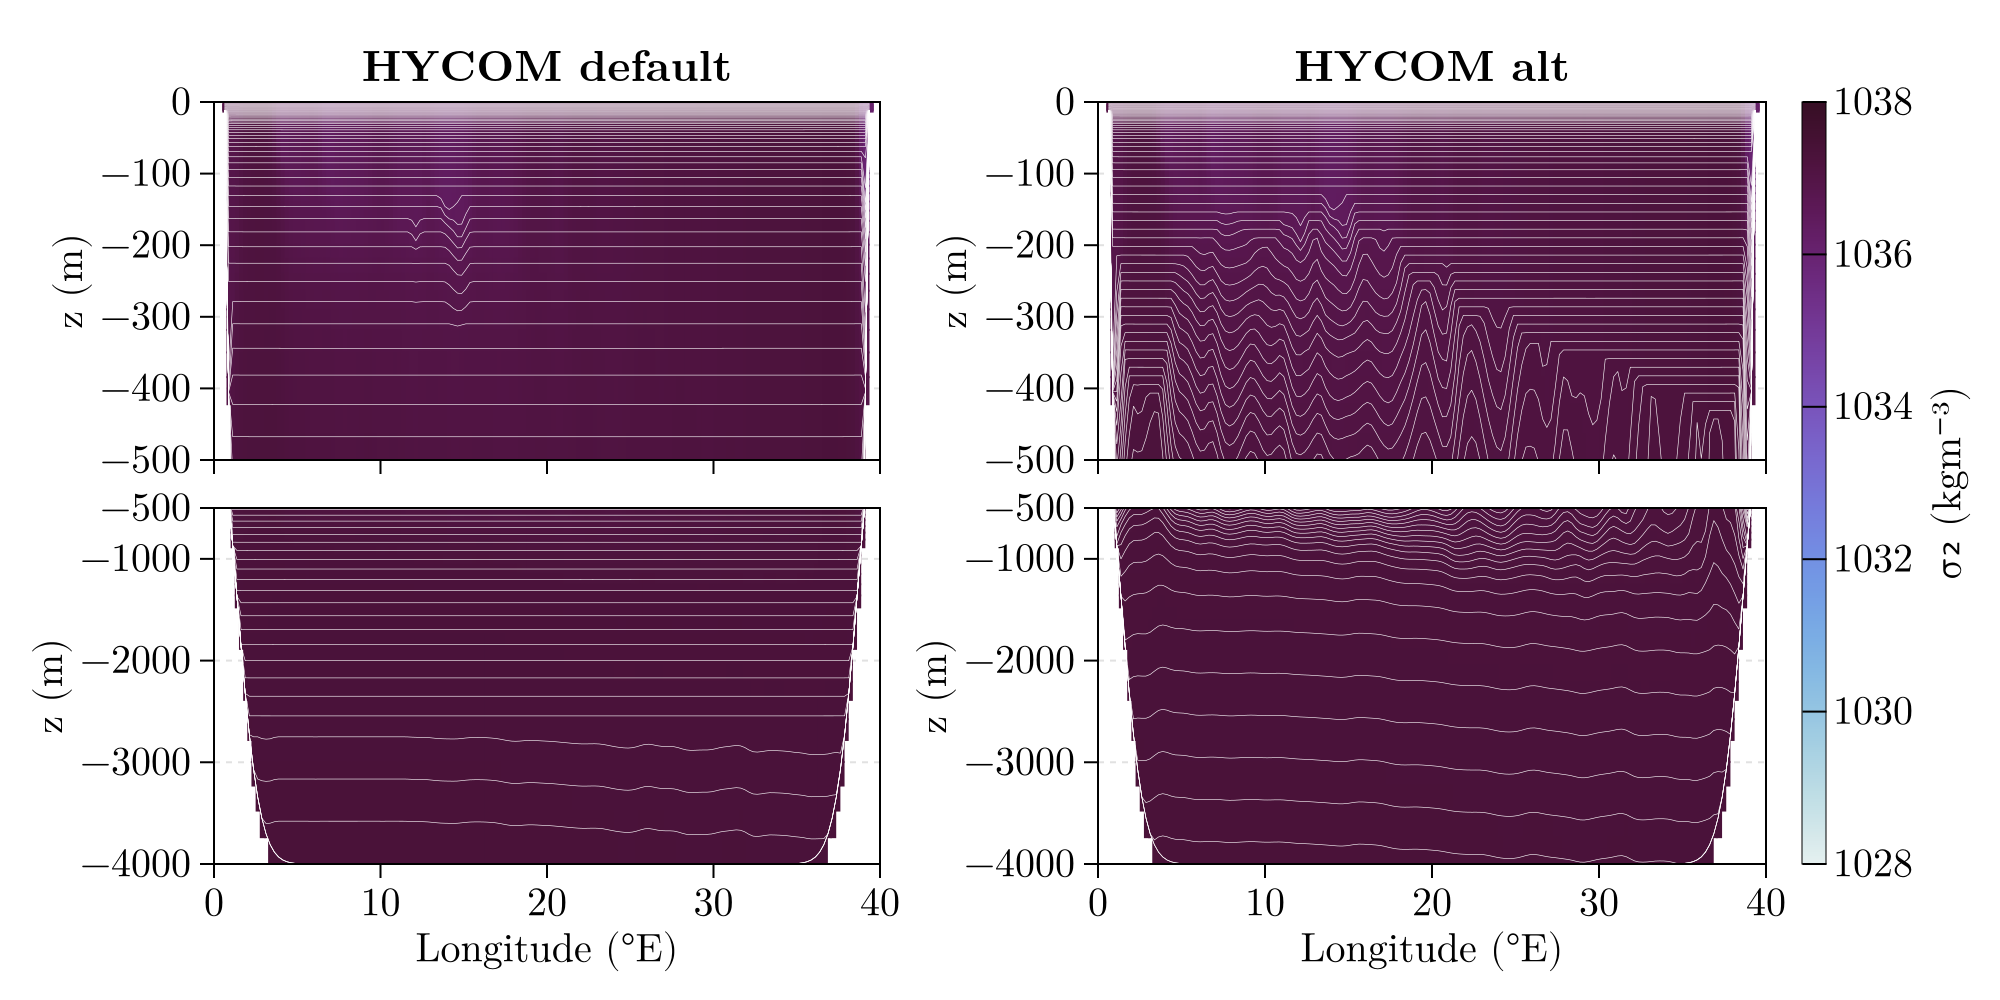

In [5]:
lat = 700
t = 1

fig = Figure(size = (1000, 500))

colormap = :dense
colorrange = (1028, 1038)
depth_levels = 1:75

# Hycom default
axtop = Axis(fig[1, 1], xlabel = "Longitude (°E)", ylabel = "z (m)", title = "HYCOM default")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, xh, -zl[depth_levels], dσ₂[:, lat, depth_levels, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axtop, xh, -∫dh[:, lat, i, t], color = :white, linewidth = 0.3)
end
ylims!(axtop, -500, 0)
axbot = Axis(fig[2, 1], xlabel = "Longitude (°E)", ylabel = "z (m)")
hm = heatmap!(axbot, xh, -zl[depth_levels], dσ₂[:, lat, depth_levels, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axbot, xh, -∫dh[:, lat, i, t], color = :white, linewidth = 0.3)
end
ylims!(axbot, -4000, -500)
axbot.yticks = [-4000, -3000, -2000, -1000, -500]

# Modified
axtop = Axis(fig[1, 2], xlabel = "Longitude (°E)", ylabel = "z (m)", title = "HYCOM alt")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, xh, -zl[depth_levels], σ₂[:, lat, depth_levels, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axtop, xh, -∫h[:, lat, i, t], color = :white, linewidth = 0.3)
end
ylims!(axtop, -500, 0)
axbot = Axis(fig[2, 2], xlabel = "Longitude (°E)", ylabel = "z (m)")
hm = heatmap!(axbot, xh, -zl[depth_levels], σ₂[:, lat, depth_levels, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axbot, xh, -∫h[:, lat, i, t], color = :white, linewidth = 0.3)
end
ylims!(axbot, -4000, -500)
axbot.yticks = [-4000, -3000, -2000, -1000, -500]

Colorbar(fig[:, 3], hm, label = "σ₂ (kgm⁻³)")

fig

## Later comparison

Currently I have the alternate HYCOM run out for five years.
This is the same density transect comparison after this length of time.

In [11]:
# alt HYCOM
output_path = joinpath(tub_output_dir, "anu-tub-nm-alt-hycom", "output001")
static = joinpath(output_path, "ocean_static.nc")
monthly = joinpath(output_path, "ocean_month.nc")
zmonthly = joinpath(output_path, "ocean_month_z.nc")

# HYCOM default
doutput_path = joinpath(tub_output_dir, "anu-tub-nm-hycom", "output001")
dmonthly = joinpath(doutput_path, "ocean_month.nc")
dzmonthly = joinpath(doutput_path, "ocean_month_z.nc")

"/g/data/e14/jb2381/anu-tub/outputs/anu-tub-nm-hycom/output001/ocean_month_z.nc"

In [17]:
ds = NCDataset(monthly, maskingvalue = NaN)
h = ds["thkcello"][:, :, :, end]
∫asvp = nanmean(nansum(ds["T_advection_scheme_variance_production"][:, :, :, :], dim = 3), dim = 3)
close(ds)

∫h = cumsum(h, dims = 3)

ds = NCDataset(zmonthly, maskingvalue = NaN)
σ₂ = ds["rhopot2"][:, :, :, end]
xh = ds["xh"][:]
yh = ds["yh"][:]
zl = ds["z_l"][:]
close(ds)

ds = NCDataset(dmonthly, maskingvalue = NaN)
dh = ds["thkcello"][:, :, :, end]
∫dasvp = nanmean(nansum(ds["T_advection_scheme_variance_production"][:, :, :, :], dim = 3), dim = 3)
close(ds)

∫dh = cumsum(dh, dims = 3)

ds = NCDataset(dzmonthly, maskingvalue = NaN)
dσ₂ = ds["rhopot2"][:, :, :, end]
xh = ds["xh"][:]
yh = ds["yh"][:]
zl = ds["z_l"][:]
close(ds)

closed Dataset

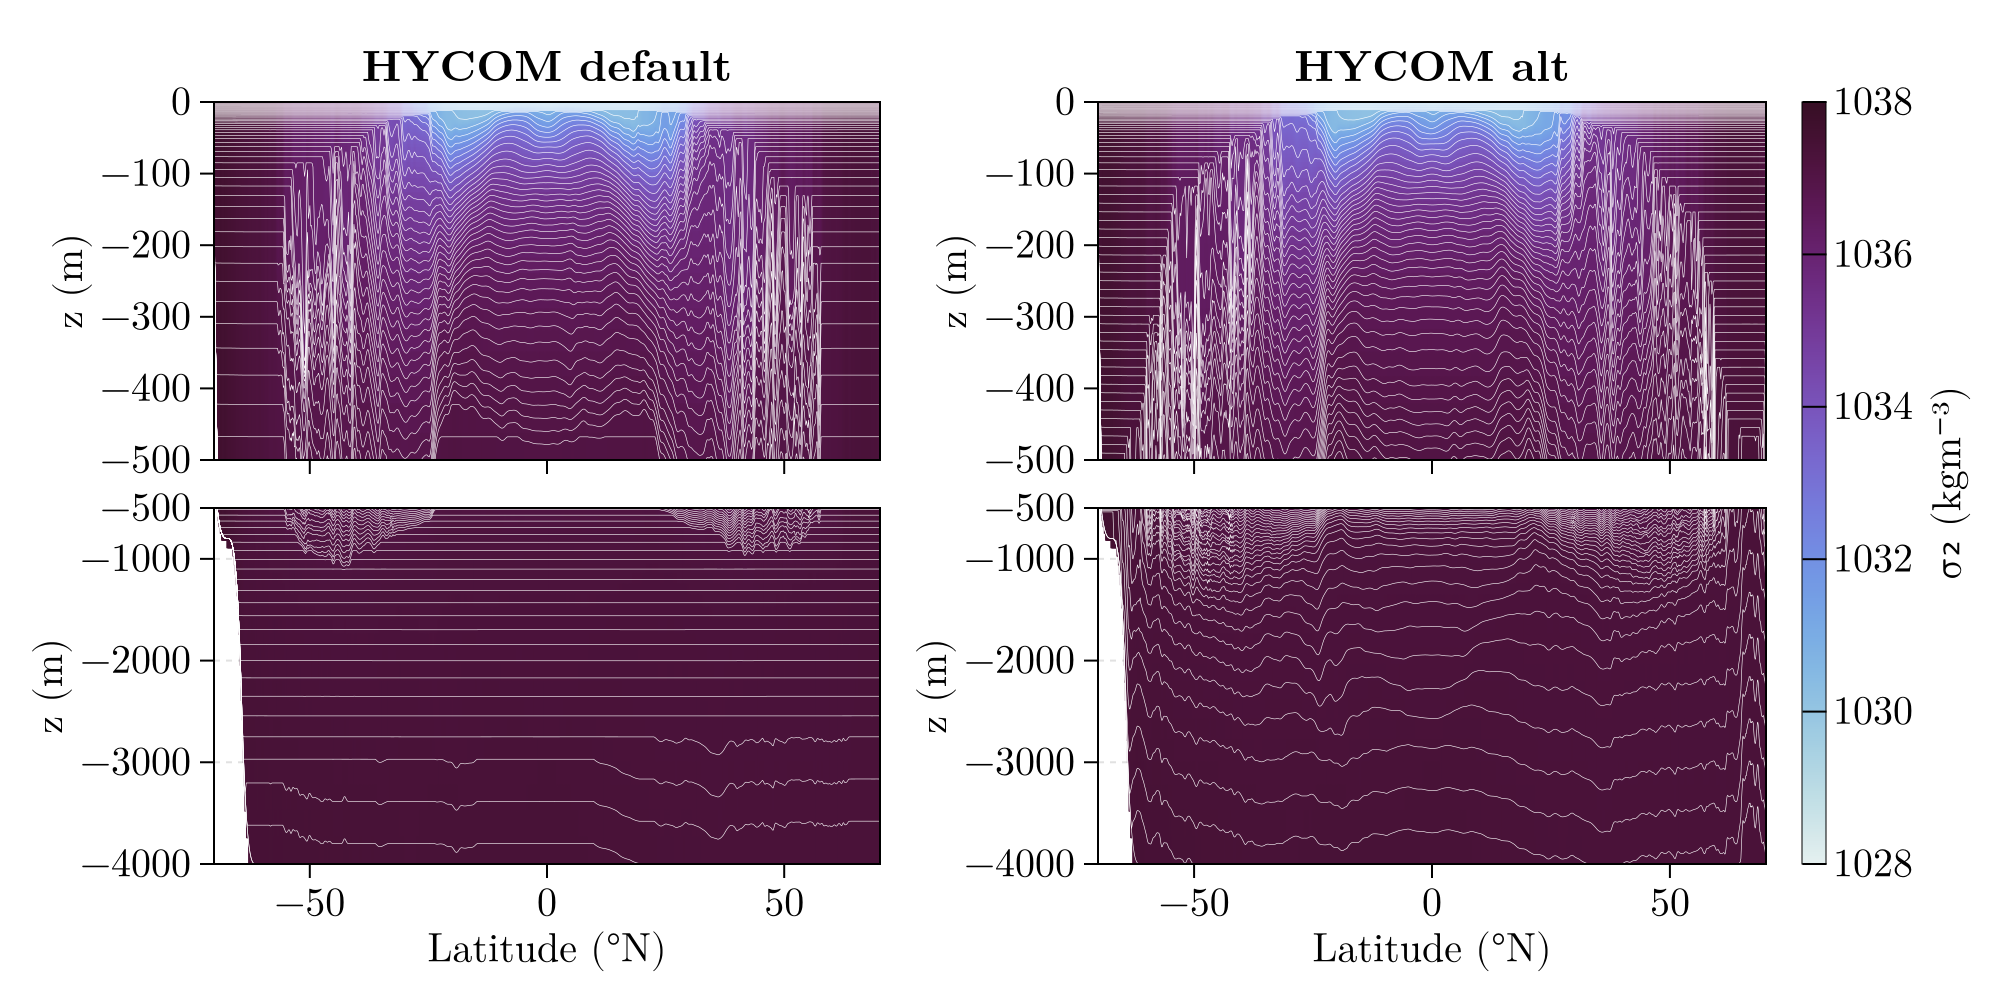

In [13]:
lon = 80
t = 1

fig = Figure(size = (1000, 500))

colormap = :dense
colorrange = (1028, 1038)
depth_levels = 1:75

# Hycom default
axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "HYCOM default")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, -zl[depth_levels], dσ₂[lon, :, depth_levels, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axtop, yh, -∫dh[lon, :, i, t], color = :white, linewidth = 0.3)
end
ylims!(axtop, -500, 0)
axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, yh, -zl[depth_levels], dσ₂[lon, :, depth_levels, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axbot, yh, -∫dh[lon, :, i, t], color = :white, linewidth = 0.3)
end
ylims!(axbot, -4000, -500)
axbot.yticks = [-4000, -3000, -2000, -1000, -500]

# Modified
axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "HYCOM alt")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, -zl[depth_levels], σ₂[lon, :, depth_levels, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axtop, yh, -∫h[lon, :, i, t], color = :white, linewidth = 0.3)
end
ylims!(axtop, -500, 0)
axbot = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, yh, -zl[depth_levels], σ₂[lon, :, depth_levels, t]; colorrange, colormap)
for i ∈ depth_levels
    lines!(axbot, yh, -∫h[lon, :, i, t], color = :white, linewidth = 0.3)
end
ylims!(axbot, -4000, -500)
axbot.yticks = [-4000, -3000, -2000, -1000, -500]

Colorbar(fig[:, 3], hm, label = "σ₂ (kgm⁻³)")

fig

Still looks good. Lastly compare the numerical mixing.

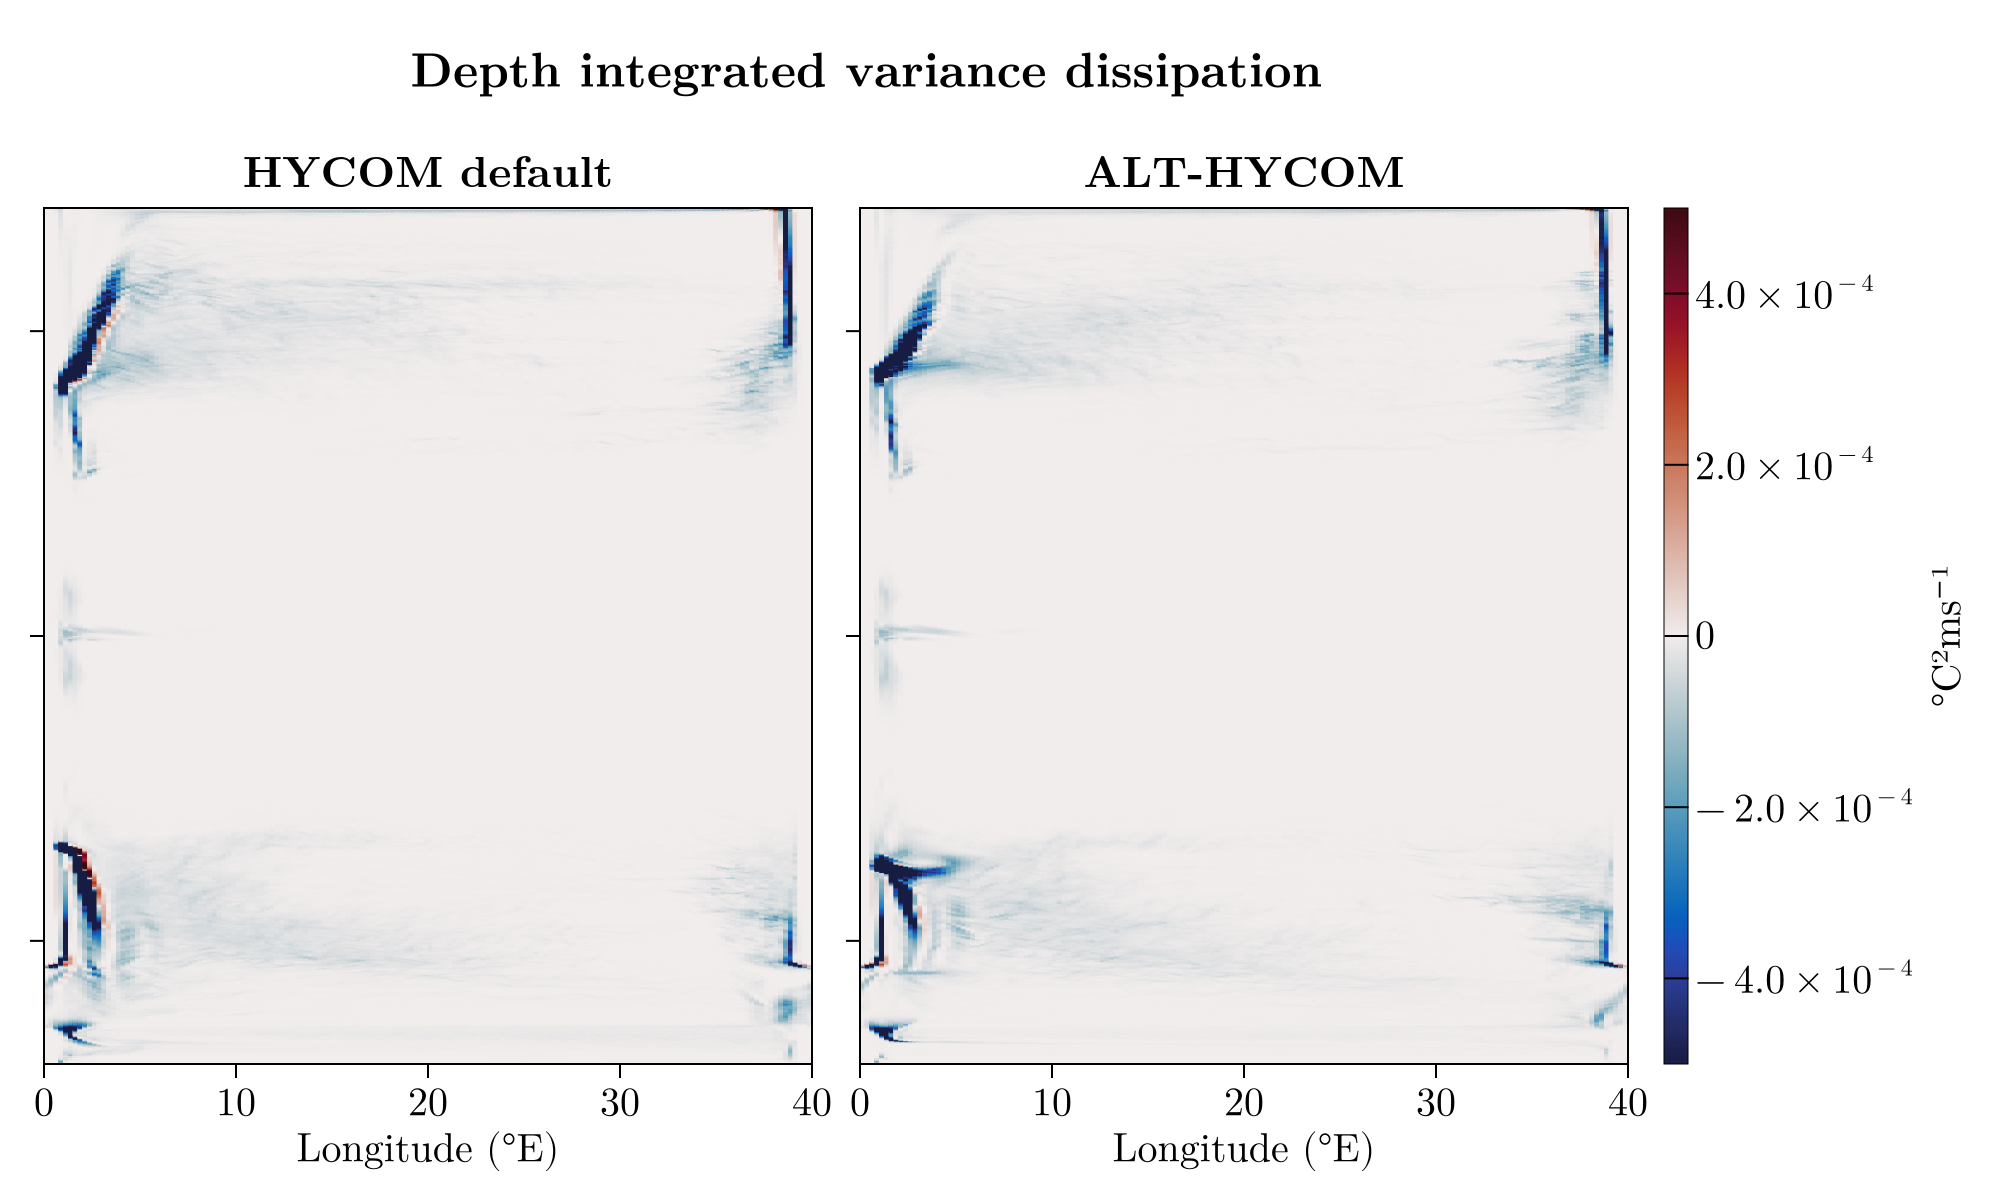

In [20]:
fig = Figure(size = (1000, 600))

colorrange = (-5e-4, 5e-4)
colormap = :balance

ax_hycomd = Axis(fig[1, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "HYCOM default")
hideydecorations!(ax_hycomd, ticks = false)
hm = heatmap!(ax_hycomd, xh, yh, ∫dasvp; colorrange, colormap)

ax_hycomdz3 = Axis(fig[1, 2], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "ALT-HYCOM")
hideydecorations!(ax_hycomdz3, ticks = false)
hm = heatmap!(ax_hycomdz3, xh, yh, ∫asvp; colorrange, colormap)

Colorbar(fig[1, 3], hm, label = "°C²ms⁻¹", tickformat = latex_format)

Label(fig[0, :], "Depth integrated variance dissipation", fontsize = 24, font = :bold)

fig